# 9.1. Working with Sequences

In [1]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

## 9.1.1. Autoregressive Models

## 9.1.2. Sequence Models

### 9.1.2.2. The Order of Decoding

## 9.1.3. Training

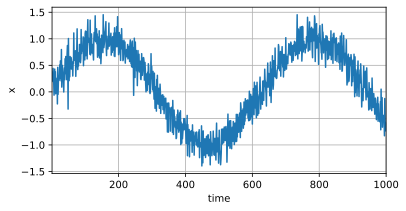

In [2]:
class Data(d2l.DataModule):
    def __init__(self, batch_size=16, T=1000, num_train=600, tau=4):
        self.save_hyperparameters()
        self.time = torch.arange(1, T + 1, dtype=torch.float32)
        self.x = torch.sin(0.01 * self.time) + torch.randn(T) * 0.2

data = Data()
d2l.plot(data.time, data.x, 'time', 'x', xlim=[1, 1000], figsize=(6, 3))

In [6]:
data.time.shape, data.x.shape

(torch.Size([1000]), torch.Size([1000]))

In [7]:
@d2l.add_to_class(Data)
def get_dataloader(self, train):
    features = [self.x[i : self.T-self.tau+i] for i in range(self.tau)]
    self.features = torch.stack(features, 1)
    self.labels = self.x[self.tau:].reshape((-1, 1))
    i = slice(0, self.num_train) if train else slice(self.num_train, None)
    return self.get_tensorloader([self.features, self.labels], train, i)

In [18]:
X, y = next(iter(data.get_dataloader(True)))
X.shape, X, y.shape, y

(torch.Size([16, 4]),
 tensor([[-0.7962, -1.3238, -1.0419, -0.8057],
         [-1.3944, -0.8680, -0.7430, -1.3356],
         [-0.9286, -0.9121, -0.8204, -0.7639],
         [ 0.8219,  0.8220,  0.9387,  0.5426],
         [-0.6309, -0.5872, -0.9020, -0.9366],
         [ 1.2964,  0.8607,  0.8816,  0.9520],
         [-0.8719, -0.9822, -0.8484, -0.6977],
         [-0.7555, -0.2968, -0.2089, -0.7583],
         [ 0.8923,  0.6228,  0.6806,  0.6971],
         [ 0.4644,  0.1558,  0.3370,  0.0016],
         [ 1.1195,  1.1538,  1.2221,  1.3227],
         [-0.5891, -1.1313, -1.1137, -1.0641],
         [-0.9051, -0.6309, -0.5872, -0.9020],
         [ 0.4199,  1.0104,  0.8411,  0.2713],
         [-0.4905, -0.7428, -0.3547, -0.4560],
         [-1.1395, -0.9115, -0.8380, -0.8967]]),
 torch.Size([16, 1]),
 tensor([[-0.4193],
         [-0.7361],
         [-0.9946],
         [ 0.7558],
         [-0.4237],
         [ 1.0430],
         [-0.8510],
         [-0.2117],
         [ 0.8586],
         [-0.0307],
  

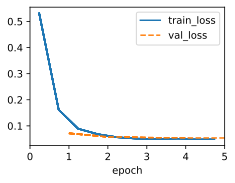

In [20]:
model = d2l.LinearRegression(lr=0.01)
trainer = d2l.Trainer(max_epochs=5)
trainer.fit(model, data)

## 9.1.4. Prediction

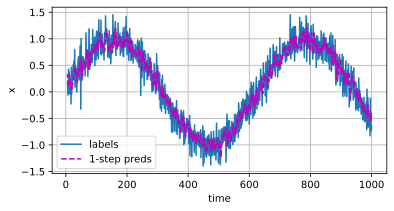

In [50]:
onestep_preds = model(data.features).detach().numpy()
d2l.plot(data.time[data.tau:], [data.labels, onestep_preds], 'time', 'x',
         legend=['labels', '1-step preds'], figsize=(6, 3))

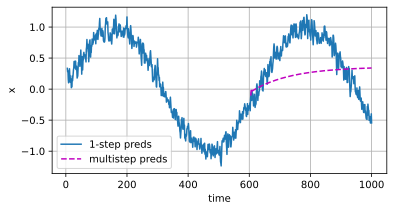

In [48]:
multistep_preds = torch.zeros(data.T)
multistep_preds[:] = data.x
for i in range(data.num_train + data.tau, data.T):
    multistep_preds[i] = model(
        multistep_preds[i - data.tau:i].reshape((1, -1)))
multistep_preds = multistep_preds.detach().numpy()

d2l.plot([data.time[data.tau:], data.time[data.num_train+data.tau:]],
         [onestep_preds, multistep_preds[data.num_train+data.tau:]], 'time',
         'x', legend=['1-step preds', 'multistep preds'], figsize=(6, 3))

In [83]:
test = data.features
for i in range(1000):
    pred = model(test[i+995]).detach()
    new_row = torch.cat([test[i+995][1:],  pred]) 
    test = torch.cat([test, new_row.unsqueeze(0)])

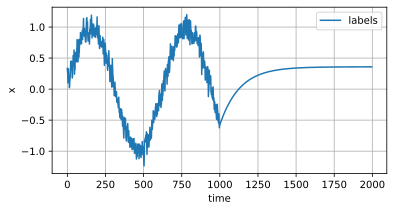

In [86]:
onestep_preds = model(test).detach().numpy()
d2l.plot(torch.arange(0, 1996), [onestep_preds], 'time', 'x',
         legend=['labels', '1-step preds'], figsize=(6, 3))

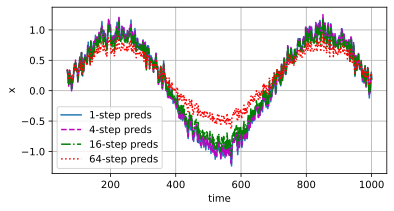

In [87]:
def k_step_pred(k):
    features = []
    for i in range(data.tau):
        features.append(data.x[i : i+data.T-data.tau-k+1])
    # The (i+tau)-th element stores the (i+1)-step-ahead predictions
    for i in range(k):
        preds = model(torch.stack(features[i : i+data.tau], 1))
        features.append(preds.reshape(-1))
    return features[data.tau:]

steps = (1, 4, 16, 64)
preds = k_step_pred(steps[-1])
d2l.plot(data.time[data.tau+steps[-1]-1:],
         [preds[k - 1].detach().numpy() for k in steps], 'time', 'x',
         legend=[f'{k}-step preds' for k in steps], figsize=(6, 3))

## Exercises & Sandbox

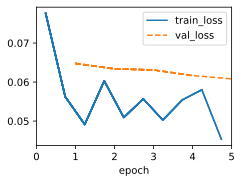

In [105]:
data = Data(tau=16)
model = d2l.LinearRegression(lr=0.01)
trainer = d2l.Trainer(max_epochs=5)
trainer.fit(model, data)

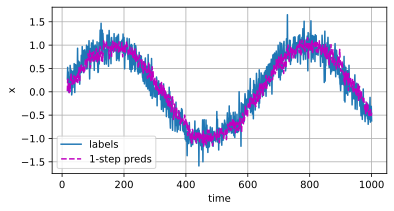

In [106]:
onestep_preds = model(data.features).detach().numpy()
d2l.plot(data.time[data.tau:], [data.labels, onestep_preds], 'time', 'x',
         legend=['labels', '1-step preds'], figsize=(6, 3))

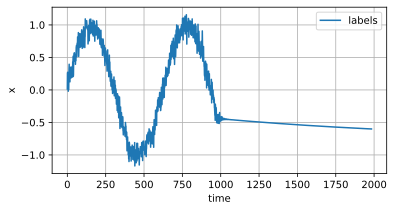

In [115]:
test = data.features
for i in range(1000):
    pred = model(test[i+983]).detach()
    new_row = torch.cat([test[i+983][1:],  pred]) 
    test = torch.cat([test, new_row.unsqueeze(0)])

onestep_preds = model(test).detach().numpy()
d2l.plot(torch.arange(0, 1984), [onestep_preds], 'time', 'x',
         legend=['labels', '1-step preds'], figsize=(6, 3))

In [117]:
class Data2(d2l.DataModule):
    def __init__(self, batch_size=16, T=1000, num_train=600, tau=4):
        self.save_hyperparameters()
        self.time = torch.arange(1, T + 1, dtype=torch.float32)
        self.x = torch.sin(0.01 * self.time)
        
    def get_dataloader(self, train):
        features = [self.x[i : self.T-self.tau+i] for i in range(self.tau)]
        self.features = torch.stack(features, 1)
        self.labels = self.x[self.tau:].reshape((-1, 1))
        i = slice(0, self.num_train) if train else slice(self.num_train, None)
        return self.get_tensorloader([self.features, self.labels], train, i)

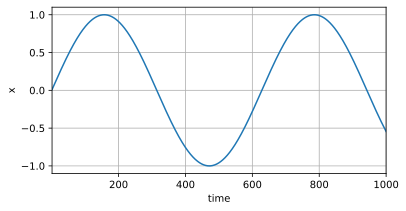

In [119]:
data2 = Data2()
d2l.plot(data2.time, data2.x, 'time', 'x', xlim=[1, 1000], figsize=(6, 3))

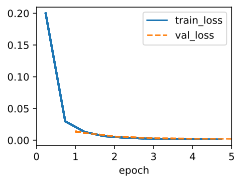

In [123]:
data = Data2(tau=8)
model = d2l.LinearRegression(lr=0.01)
trainer = d2l.Trainer(max_epochs=5)
trainer.fit(model, data)

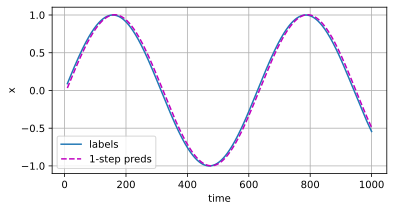

In [124]:
onestep_preds = model(data.features).detach().numpy()
d2l.plot(data.time[data.tau:], [data.labels, onestep_preds], 'time', 'x',
         legend=['labels', '1-step preds'], figsize=(6, 3))

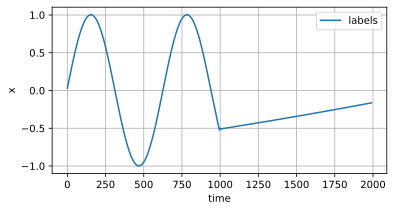

In [129]:
test = data.features
for i in range(1000):
    pred = model(test[i+991]).detach()
    new_row = torch.cat([test[i+991][1:],  pred]) 
    test = torch.cat([test, new_row.unsqueeze(0)])

onestep_preds = model(test).detach().numpy()
d2l.plot(torch.arange(0, 1992), [onestep_preds], 'time', 'x',
         legend=['labels', '1-step preds'], figsize=(6, 3))